<a href="https://colab.research.google.com/github/Ehsan-Roohi/FlowMLLab/blob/main/notebooks/week04/W4_Lab4_Stokes_to_Navier_Stokes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

# Week 4 - Lab 4: Stokes-to-Navier-Stokes correction

<!-- MIE690A article-aligned validation v4 -->

This lab uses an actual Stokes solution and Reynolds number to predict the nonlinear correction required by the steady Navier-Stokes solution. It is a data-driven correction experiment, not weight transfer from a Stokes network.

## Learning goals

1. Separate a low-fidelity physical solution from a learned correction.
2. Keep Reynolds-number changes consistent with velocity changes.
3. Compare constant and spatially diverse lid boundary conditions.
4. Evaluate all four train/test family combinations and two out-of-distribution groups.
5. Distinguish same-grid surrogate accuracy from mesh-independent CFD validation.

In [1]:
# FLOWMLLAB_COLAB_BOOTSTRAP_V1
from pathlib import Path as _FlowMLLabPath
import os as _flowmllab_os
import subprocess as _flowmllab_subprocess
import sys as _flowmllab_sys

if "google.colab" in _flowmllab_sys.modules or _flowmllab_os.environ.get("COLAB_RELEASE_TAG"):
    _flowmllab_root = _FlowMLLabPath("/content/FlowMLLab")
    if not (_flowmllab_root / ".git").is_dir():
        _flowmllab_subprocess.run(
            ["git", "clone", "--depth", "1",
             "https://github.com/Ehsan-Roohi/FlowMLLab.git", str(_flowmllab_root)],
            check=True,
        )
    _flowmllab_subprocess.run(
        [_flowmllab_sys.executable, "-m", "pip", "install", "-q", "-e", str(_flowmllab_root)],
        check=True,
    )
    _flowmllab_os.chdir(_flowmllab_root)
    if str(_flowmllab_root) not in _flowmllab_sys.path:
        _flowmllab_sys.path.insert(0, str(_flowmllab_root))
    print("FlowMLLab ready:", _flowmllab_root)
else:
    print("Using the current local FlowMLLab checkout.")

Using the current local FlowMLLab checkout.


In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'results/stokes_refined').exists():
    raise RuntimeError('Run from the FlowMLLab repository root.')
R = ROOT / 'results/stokes_refined'
print({'repository_root': '.', 'result_directory': 'results/stokes_refined'})

{'repository_root': '.', 'result_directory': 'results/stokes_refined'}


## 1. Reynolds number and boundary-condition families

The dimensional reference speed is not independent of Reynolds number:

$$Re=\frac{U_{ref}L}{\nu}, \qquad U_{ref}=\frac{Re\,\nu}{L},$$

with $L=1$ and $\nu=0.0025$ in this experiment. The constant family uses

$$U_{lid}(x)=U_{ref}.$$

The diverse family uses a positive, max-normalized Fourier profile

$$U_{lid}(x)=U_{ref}\,\frac{1+\sum_{k=1}^{3}a_k\sin(k\pi x/L)}{\max_{0\leq\xi\leq L}\left|1+\sum_{k=1}^{3}a_k\sin(k\pi \xi/L)\right|}.$$

The held-out shape group activates five modes with larger total amplitude. The Reynolds OOD group uses $450<Re<600$ instead of the training interval $100<Re<400$.

In [3]:
manifest = json.loads((ROOT/'results/cavity_diversity_pilot/manifest.json').read_text())
cases = manifest['cases']
pd.DataFrame(cases).groupby(['family','split']).size().rename('cases').to_frame()

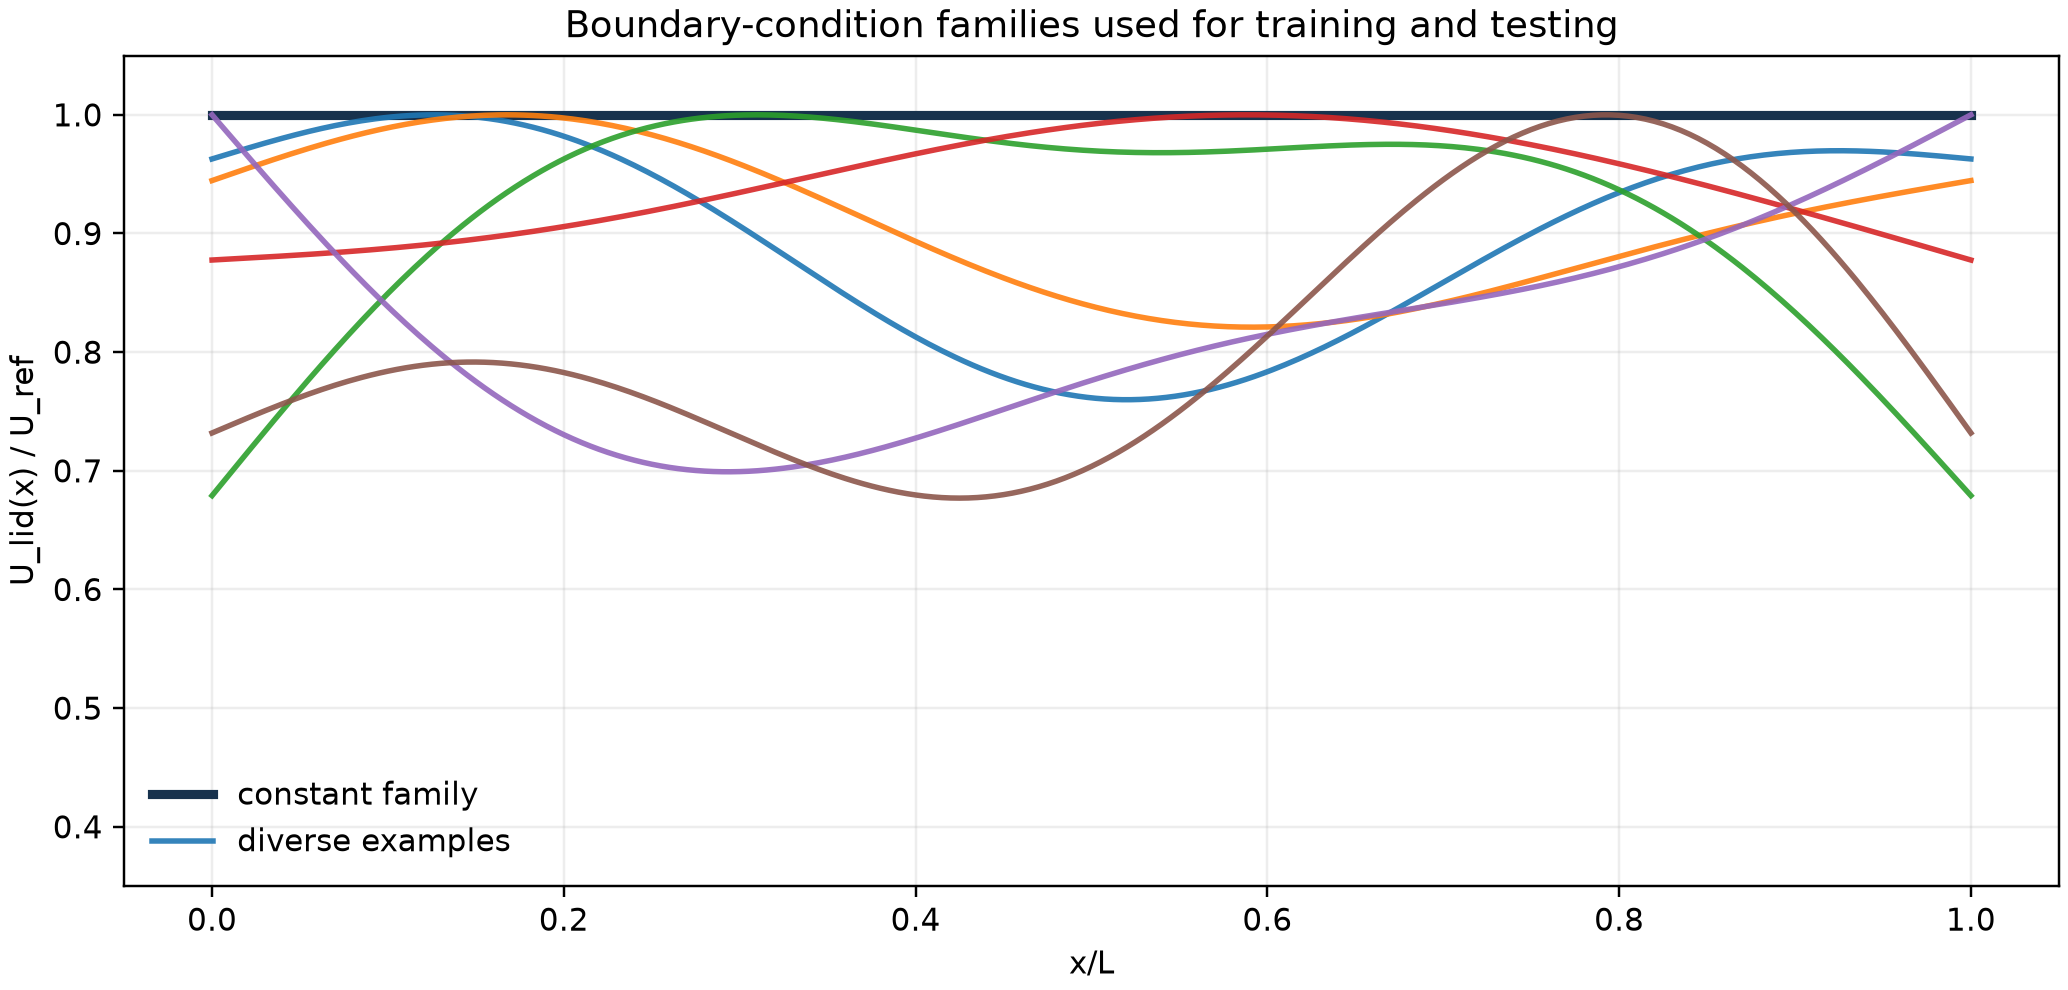

In [4]:
display(Image(filename=str(R/'week04_2_lid_families.png')))

## 2. Physical baseline and correction target

For an incompressible velocity field $\mathbf{u}$, the steady equations are

$$\nabla\cdot\mathbf{u}=0, \qquad (\mathbf{u}\cdot\nabla)\mathbf{u}=-\nabla p+Re^{-1}\nabla^2\mathbf{u}.$$

The Stokes baseline deletes only the nonlinear convection term. With streamfunction $\psi$, $u=\partial_y\psi$ and $v=-\partial_x\psi$. The network predicts a streamfunction correction,

$$\psi_{NS}=\psi_S+\Delta\psi_\theta(\psi_S,Re),$$

so the velocity correction follows by differentiation. Pressure is recovered afterwards from the momentum gradients; pressure is not a network output.

In [5]:
audit = json.loads((ROOT/'results/stokes_correction/solver_audit.json').read_text())
audit

## 3. Numerical data contract

- The Navier-Stokes labels use a streamfunction-vorticity finite-difference solver on an $n=25$ grid.
- Batched midpoint RK2 advances vorticity; a discrete sine transform solves the Poisson equation.
- Labels are accepted only after the steady PDE residual passes twice.
- The Stokes system uses the same grid, lid data, streamfunction convention, and wall-vorticity closure.
- Train, validation, test, shape-OOD, and Reynolds-OOD cases are separated by complete flow case.

In [6]:
status_same = json.loads((R/'same_data/status.json').read_text())
status_expanded = json.loads((R/'expanded/status.json').read_text())
display(pd.DataFrame([status_same, status_expanded], index=['same_data','expanded']))

,stage,complete,train_per_family,validation_per_family,test_status,selection
same_data,same_data,True,16,4,same original pilot regression tests,validation only; mean ensemble predetermined
expanded,expanded,True,64,16,same original pilot regression tests,validation only; mean ensemble predetermined


## 4. Network architecture

The low-fidelity Stokes snapshots are compressed by a training-only POD basis. A second training-only POD basis represents the target correction. The MLP receives

$$\mathbf{z}=[Re/400,\;\log(Re/400),\;\widehat{\mathbf{a}}_S]$$

and predicts scaled correction coefficients. Candidate ranks and widths are $(12,64)$, $(24,64)$, and $(24,96)$. The selected model uses correction rank 24, two 96-neuron tanh hidden layers, and a linear rank-24 output. Selection uses validation velocity error only. Seeds 7, 17, and 27 are averaged after selection.

In [7]:
selection = pd.read_csv(R/'expanded/selection.csv')
selection[['family','rank','width','omega_weight','seed','validation','chosen_step','seconds']].round(5)

## 5. Derivative-aware objective

Training minimizes a quadratic Sobolev metric in coefficient space,

$$\mathcal{L}=\|\Delta\psi_\theta-\Delta\psi\|_2^2
+\lambda_u\|\nabla(\Delta\psi_\theta-\Delta\psi)\|_2^2
+\lambda_\omega\|\nabla^2(\Delta\psi_\theta-\Delta\psi)\|_2^2.$$

Adam runs for 1800 epochs with cosine learning-rate decay. L-BFGS starts from the validation-selected Adam checkpoint. Checkpoint choice never uses a test field.

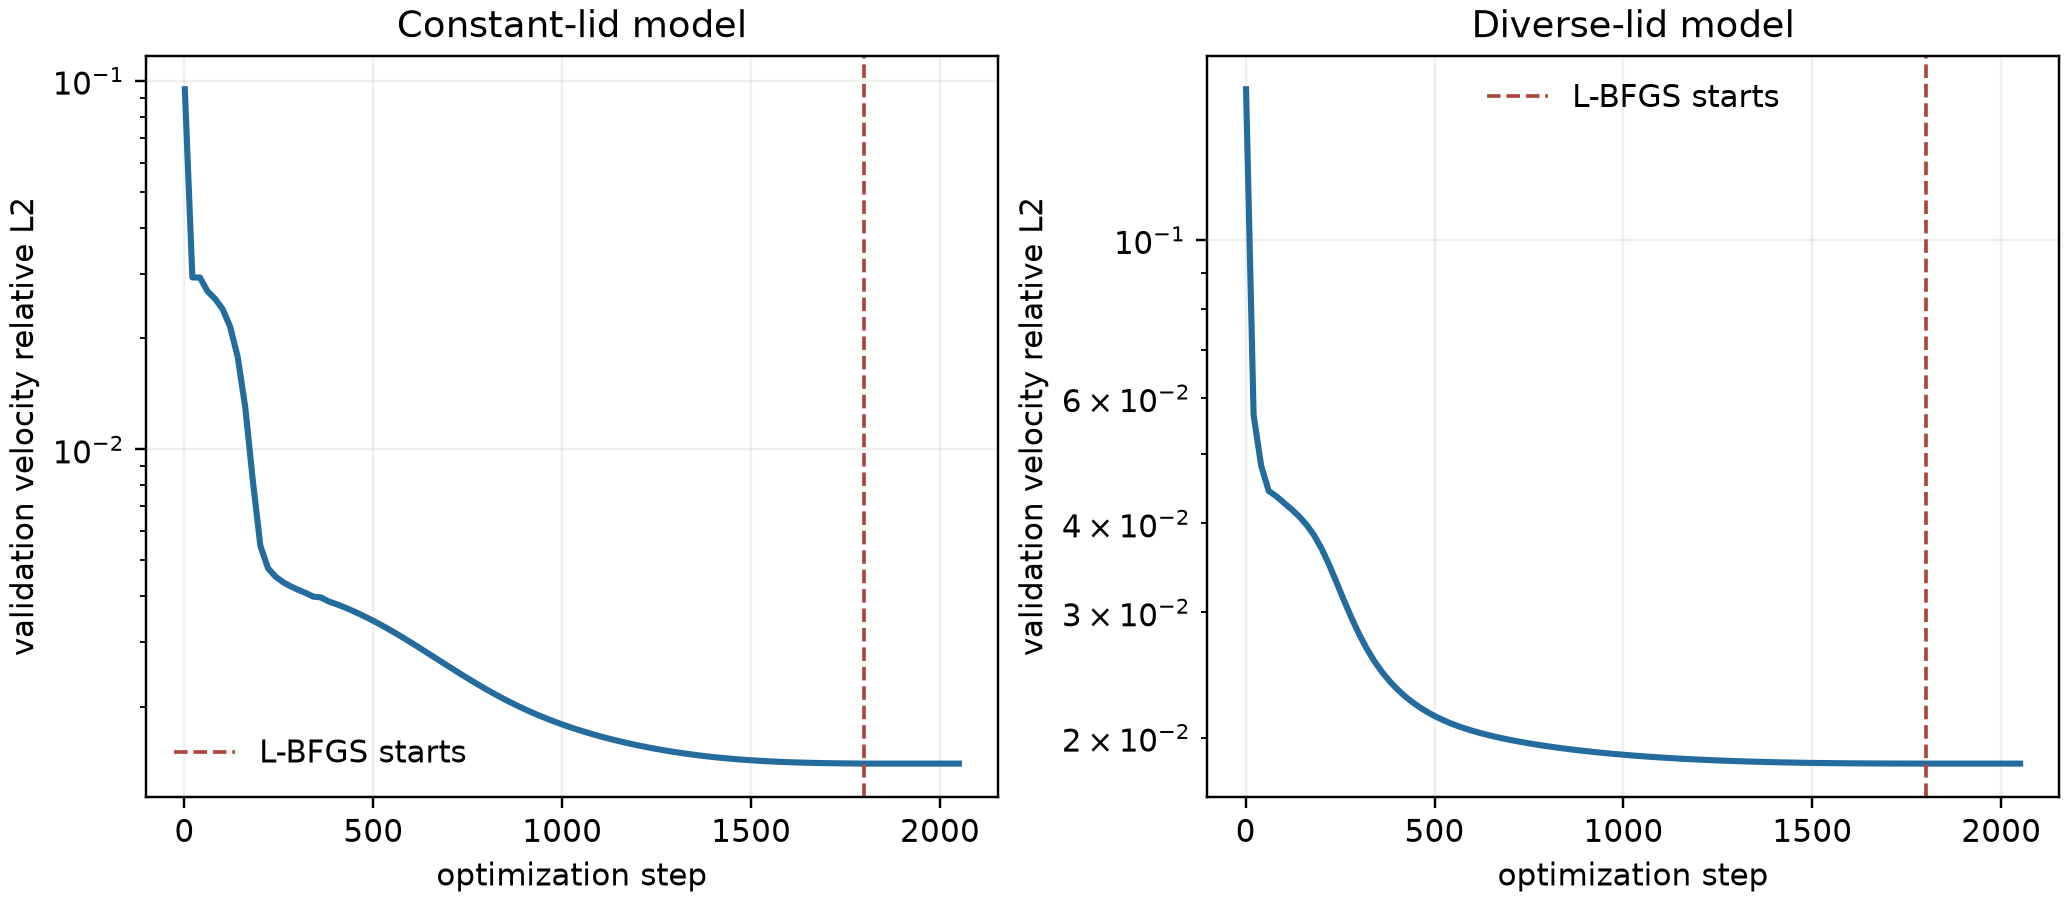

In [8]:
display(Image(filename=str(R/'week04_2_validation_history.png')))

## 6. Optional regeneration

The retained checkpoints and predictions make the default notebook fast and deterministic. Set the switch below only when you intend to repeat the full dataset/training workflow. Numerical values can vary slightly with BLAS and PyTorch versions.

In [9]:
RUN_TRAINING = False
if RUN_TRAINING:
    from flowmllab.stokes_refined import run
    run('same_data')
    run('expanded')
else:
    print('Using retained predictions; training was not rerun.')

Using retained predictions; training was not rerun.


## 7. Velocity results on unchanged regression tests

The expanded stage adds training and validation cases but retains the original test cases. Therefore, the comparison isolates the effect of optimization and additional training data on the same inspected regression set; it is not a new blind benchmark.

In [10]:
comparison = pd.read_csv(R/'comparison.csv')
main = comparison[comparison.test.isin(['constant','diverse'])]
main.pivot(index=['train','test'], columns='model', values='velocity_percent').round(3)

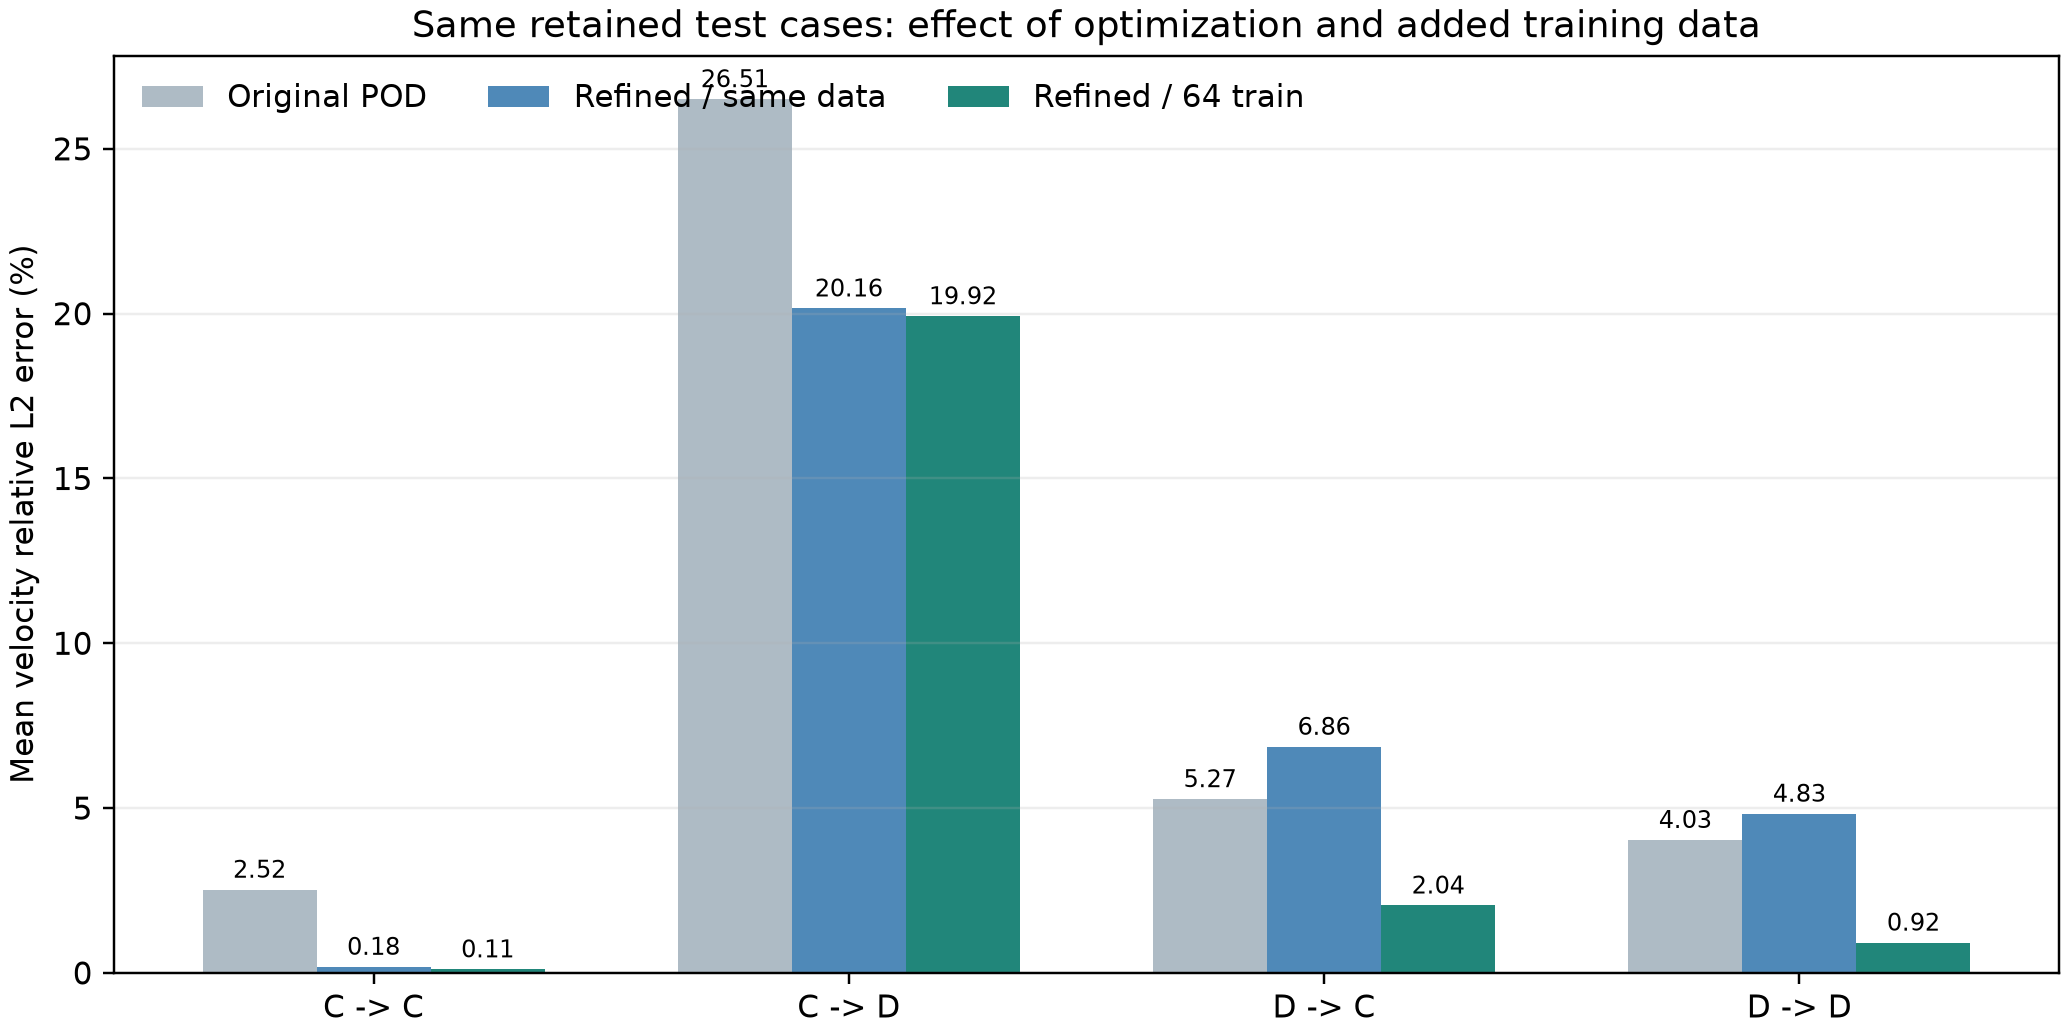

In [11]:
display(Image(filename=str(R/'week04_2_error_matrix.png')))

## 8. Pressure recovery audit

Pressure has zero global mean. The reference pressure and predicted pressure are both recovered from their velocity fields using the same least-squares momentum-gradient method. Core errors remove two boundary layers and align the core gauge separately. This is a consistency comparison, not validation against an independently solved pressure field.

In [12]:
pressure = pd.read_csv(R/'pressure_metrics.csv')
pressure.groupby(['train','test'])[['pressure_full_percent','pressure_core_percent','gradient_residual']].mean().round(3)

The following fields are linearly interpolated for display only. Numerical samples and all errors remain on the original 25 x 25 grid.

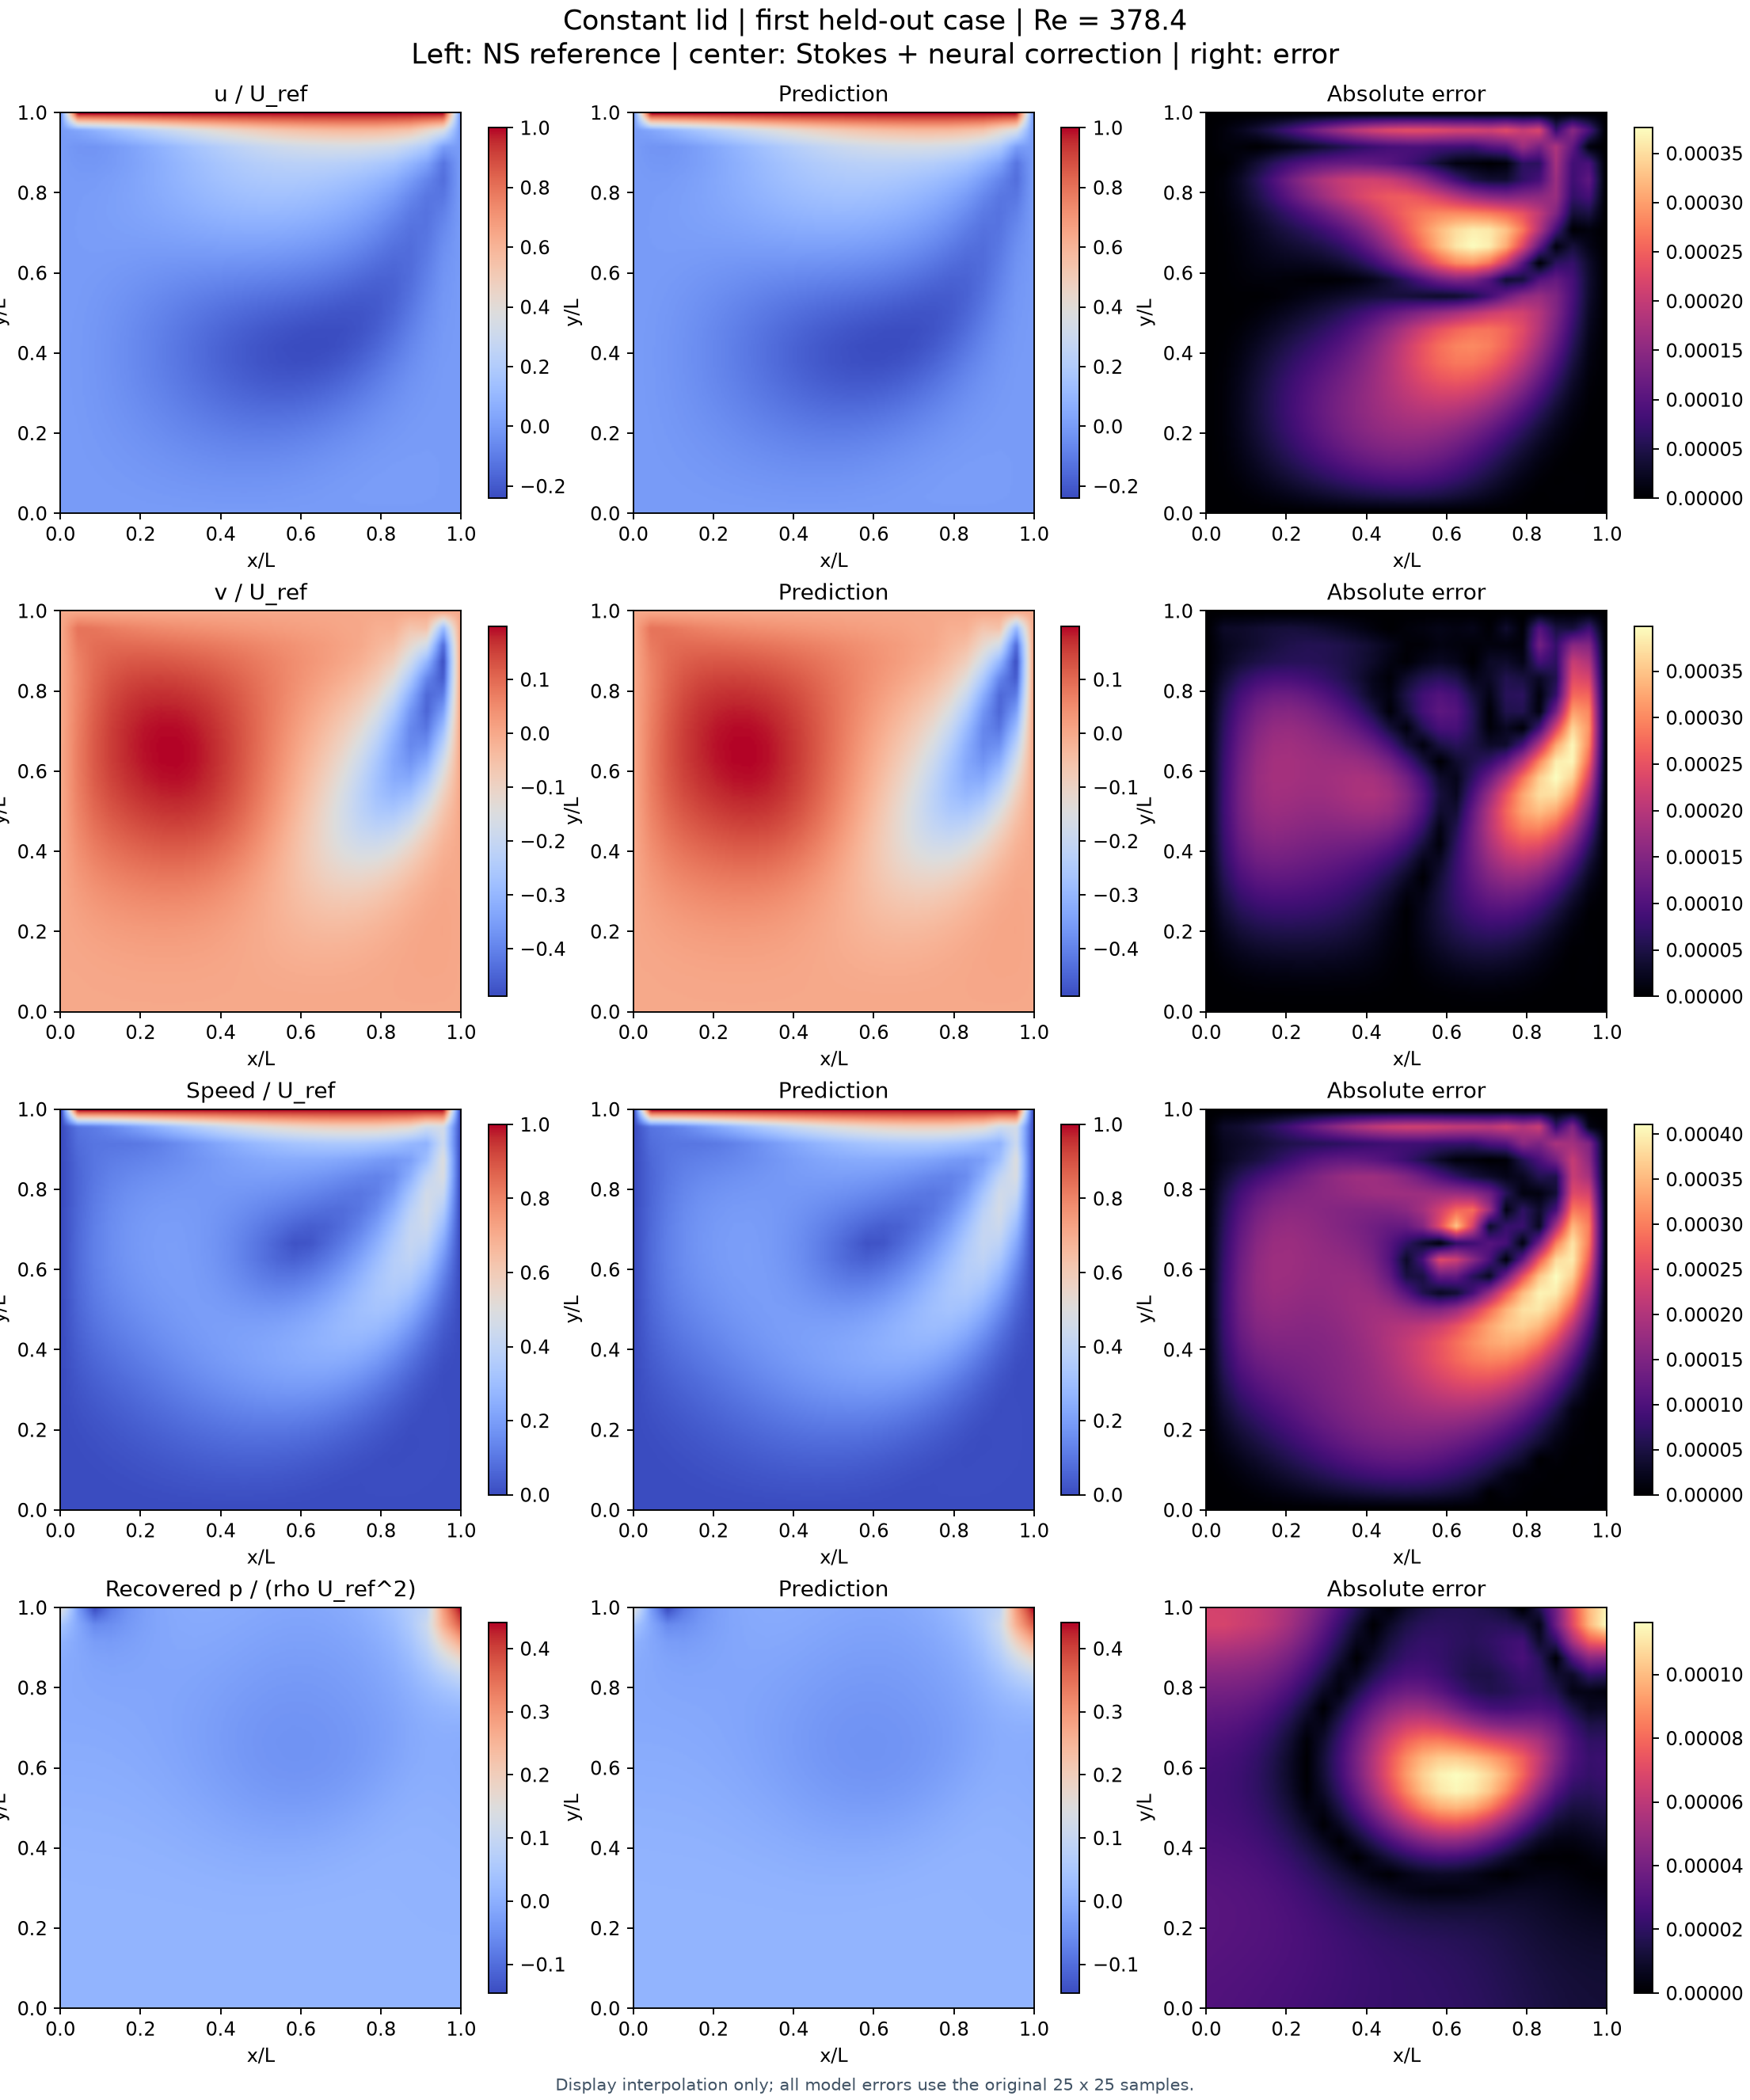

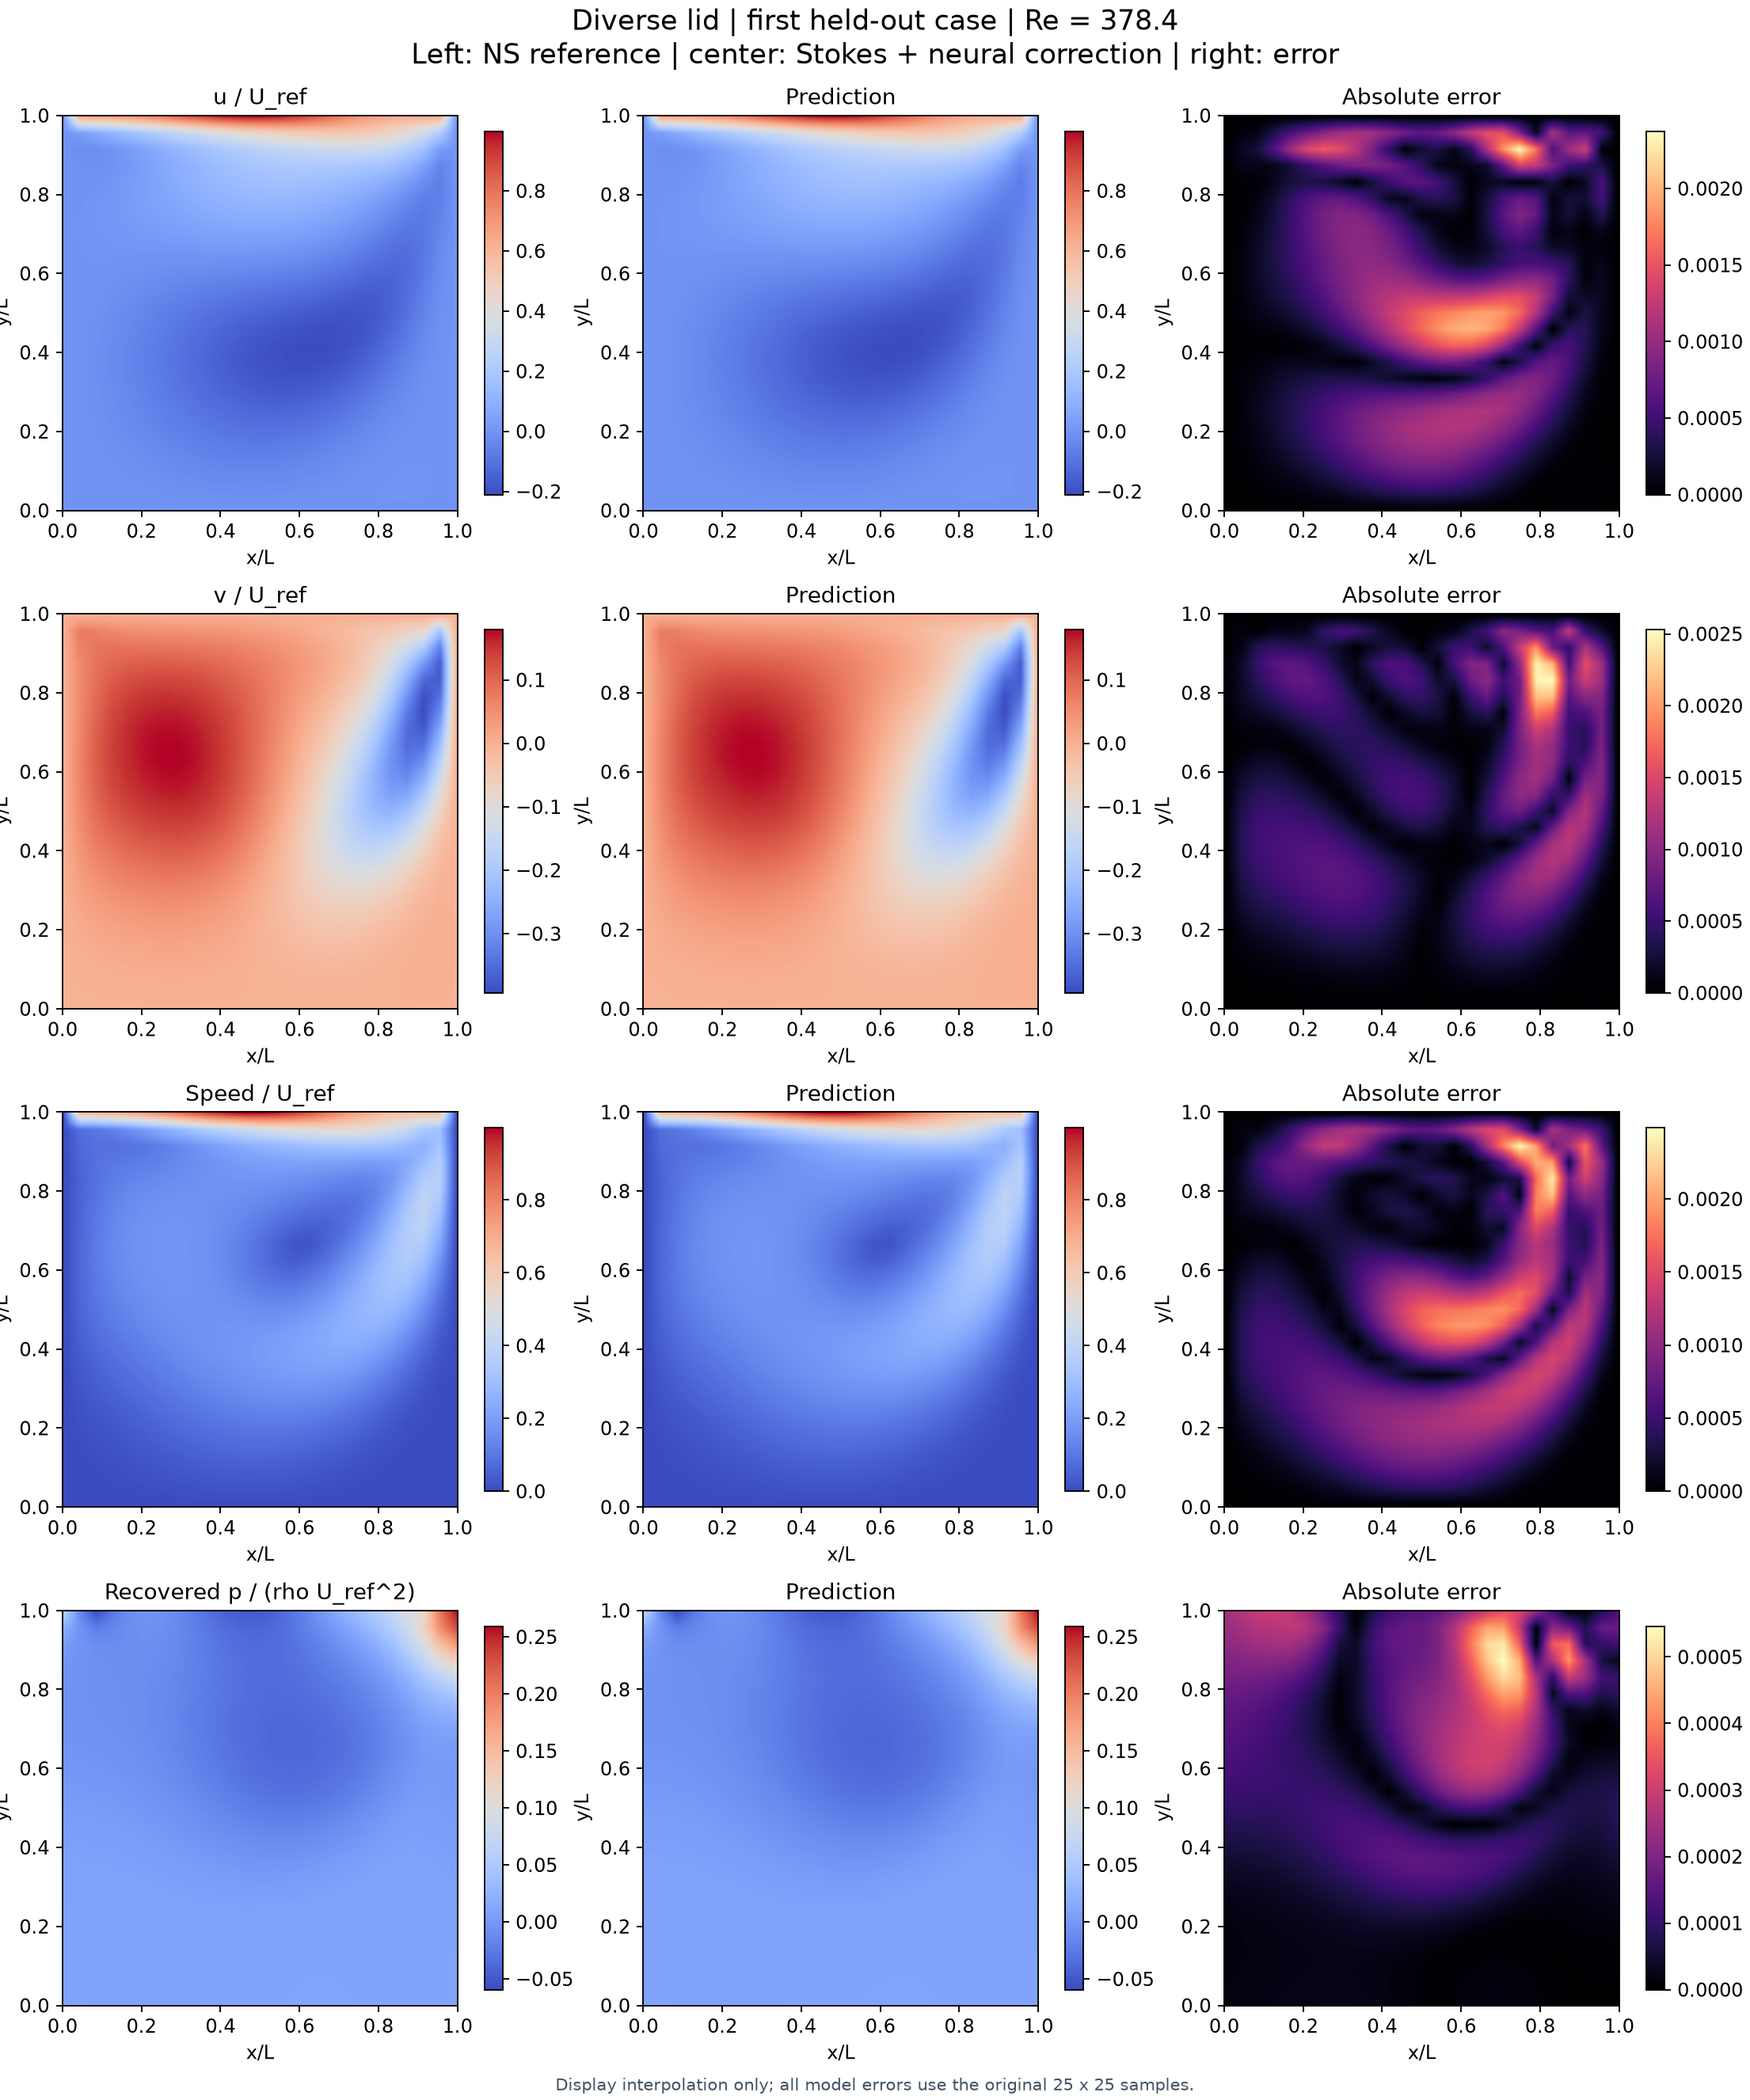

In [13]:
display(Image(filename=str(ROOT/'figures/Cavity_constant_velocity_pressure.png')))
display(Image(filename=str(ROOT/'figures/Cavity_diverse_velocity_pressure.png')))

## 9. Streamlines and vortex capture

The speed maps below overlay streamlines from the original `n=25` velocity samples. Orange circles mark the primary streamfunction minimum; pink triangles mark the positive streamfunction maximum in the lower-right corner. Interior vorticity is computed with the same discrete `-Laplacian(psi)` operator for reference and prediction. Colors are interpolated for display only. The secondary corner feature is a grid-resolved recirculation candidate, not an independently validated vortex core.

,mean,max
family,,
constant,0.0012,0.0015
diverse,0.0149,0.0324


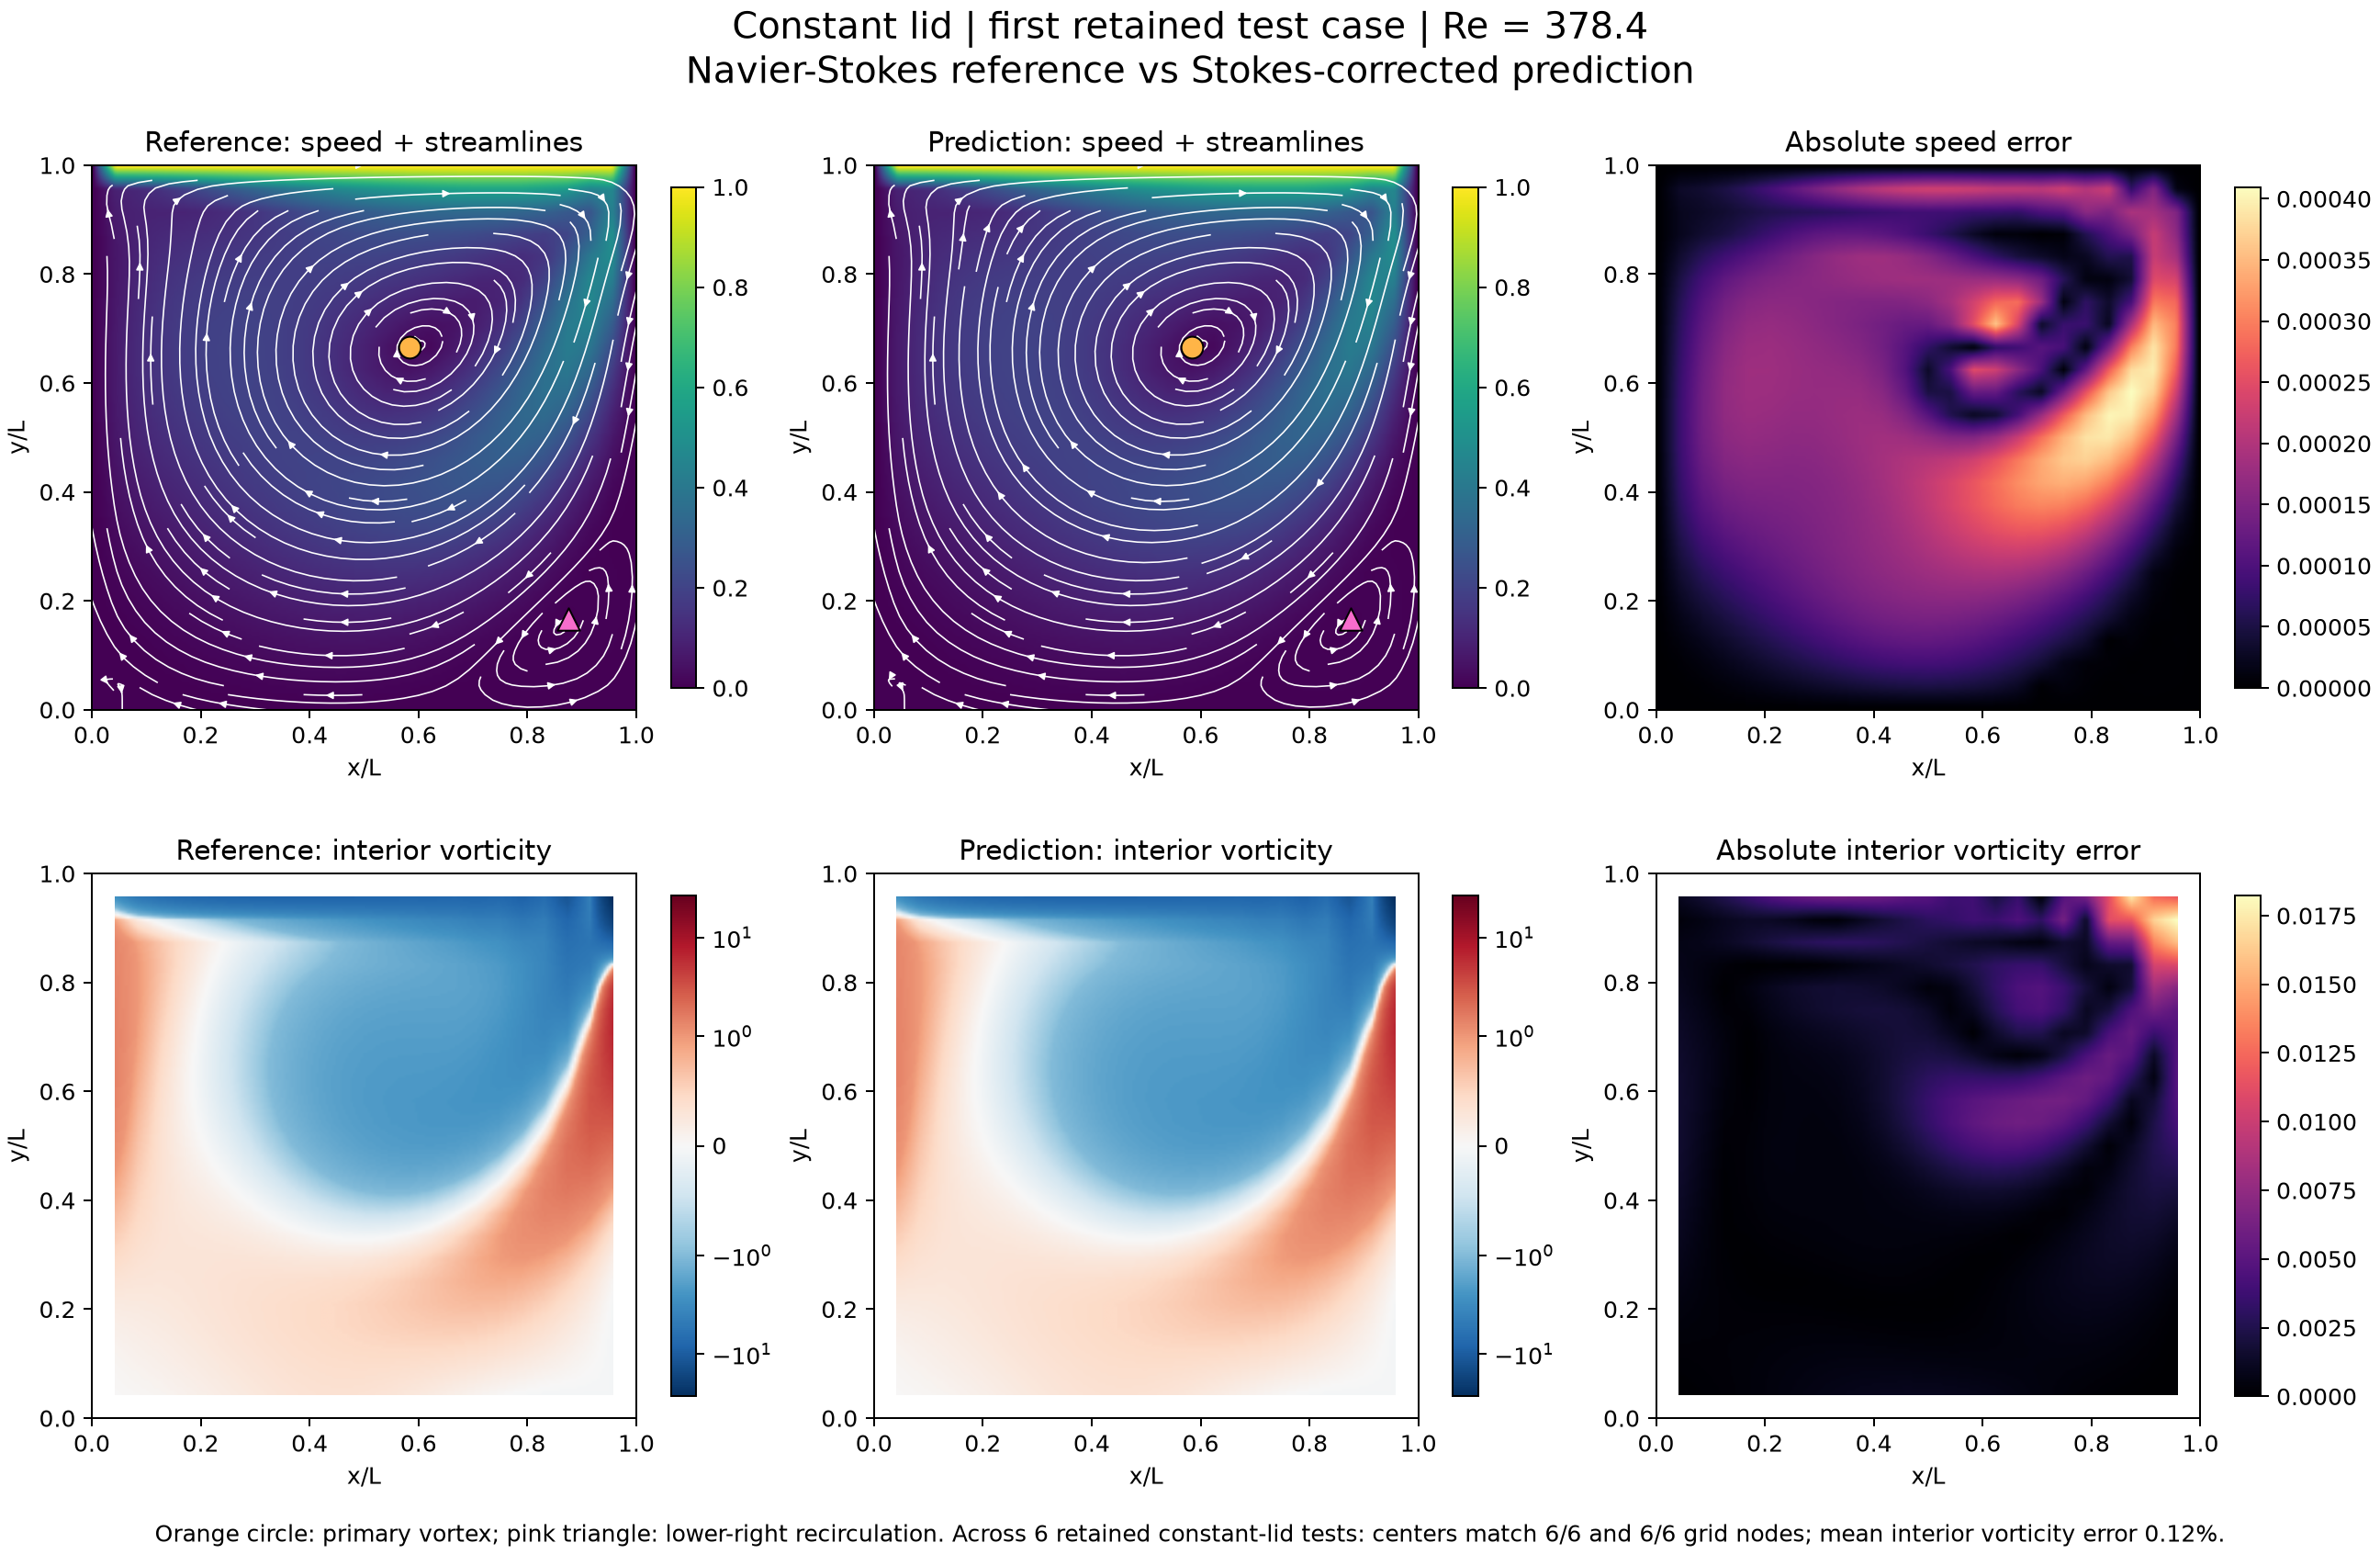

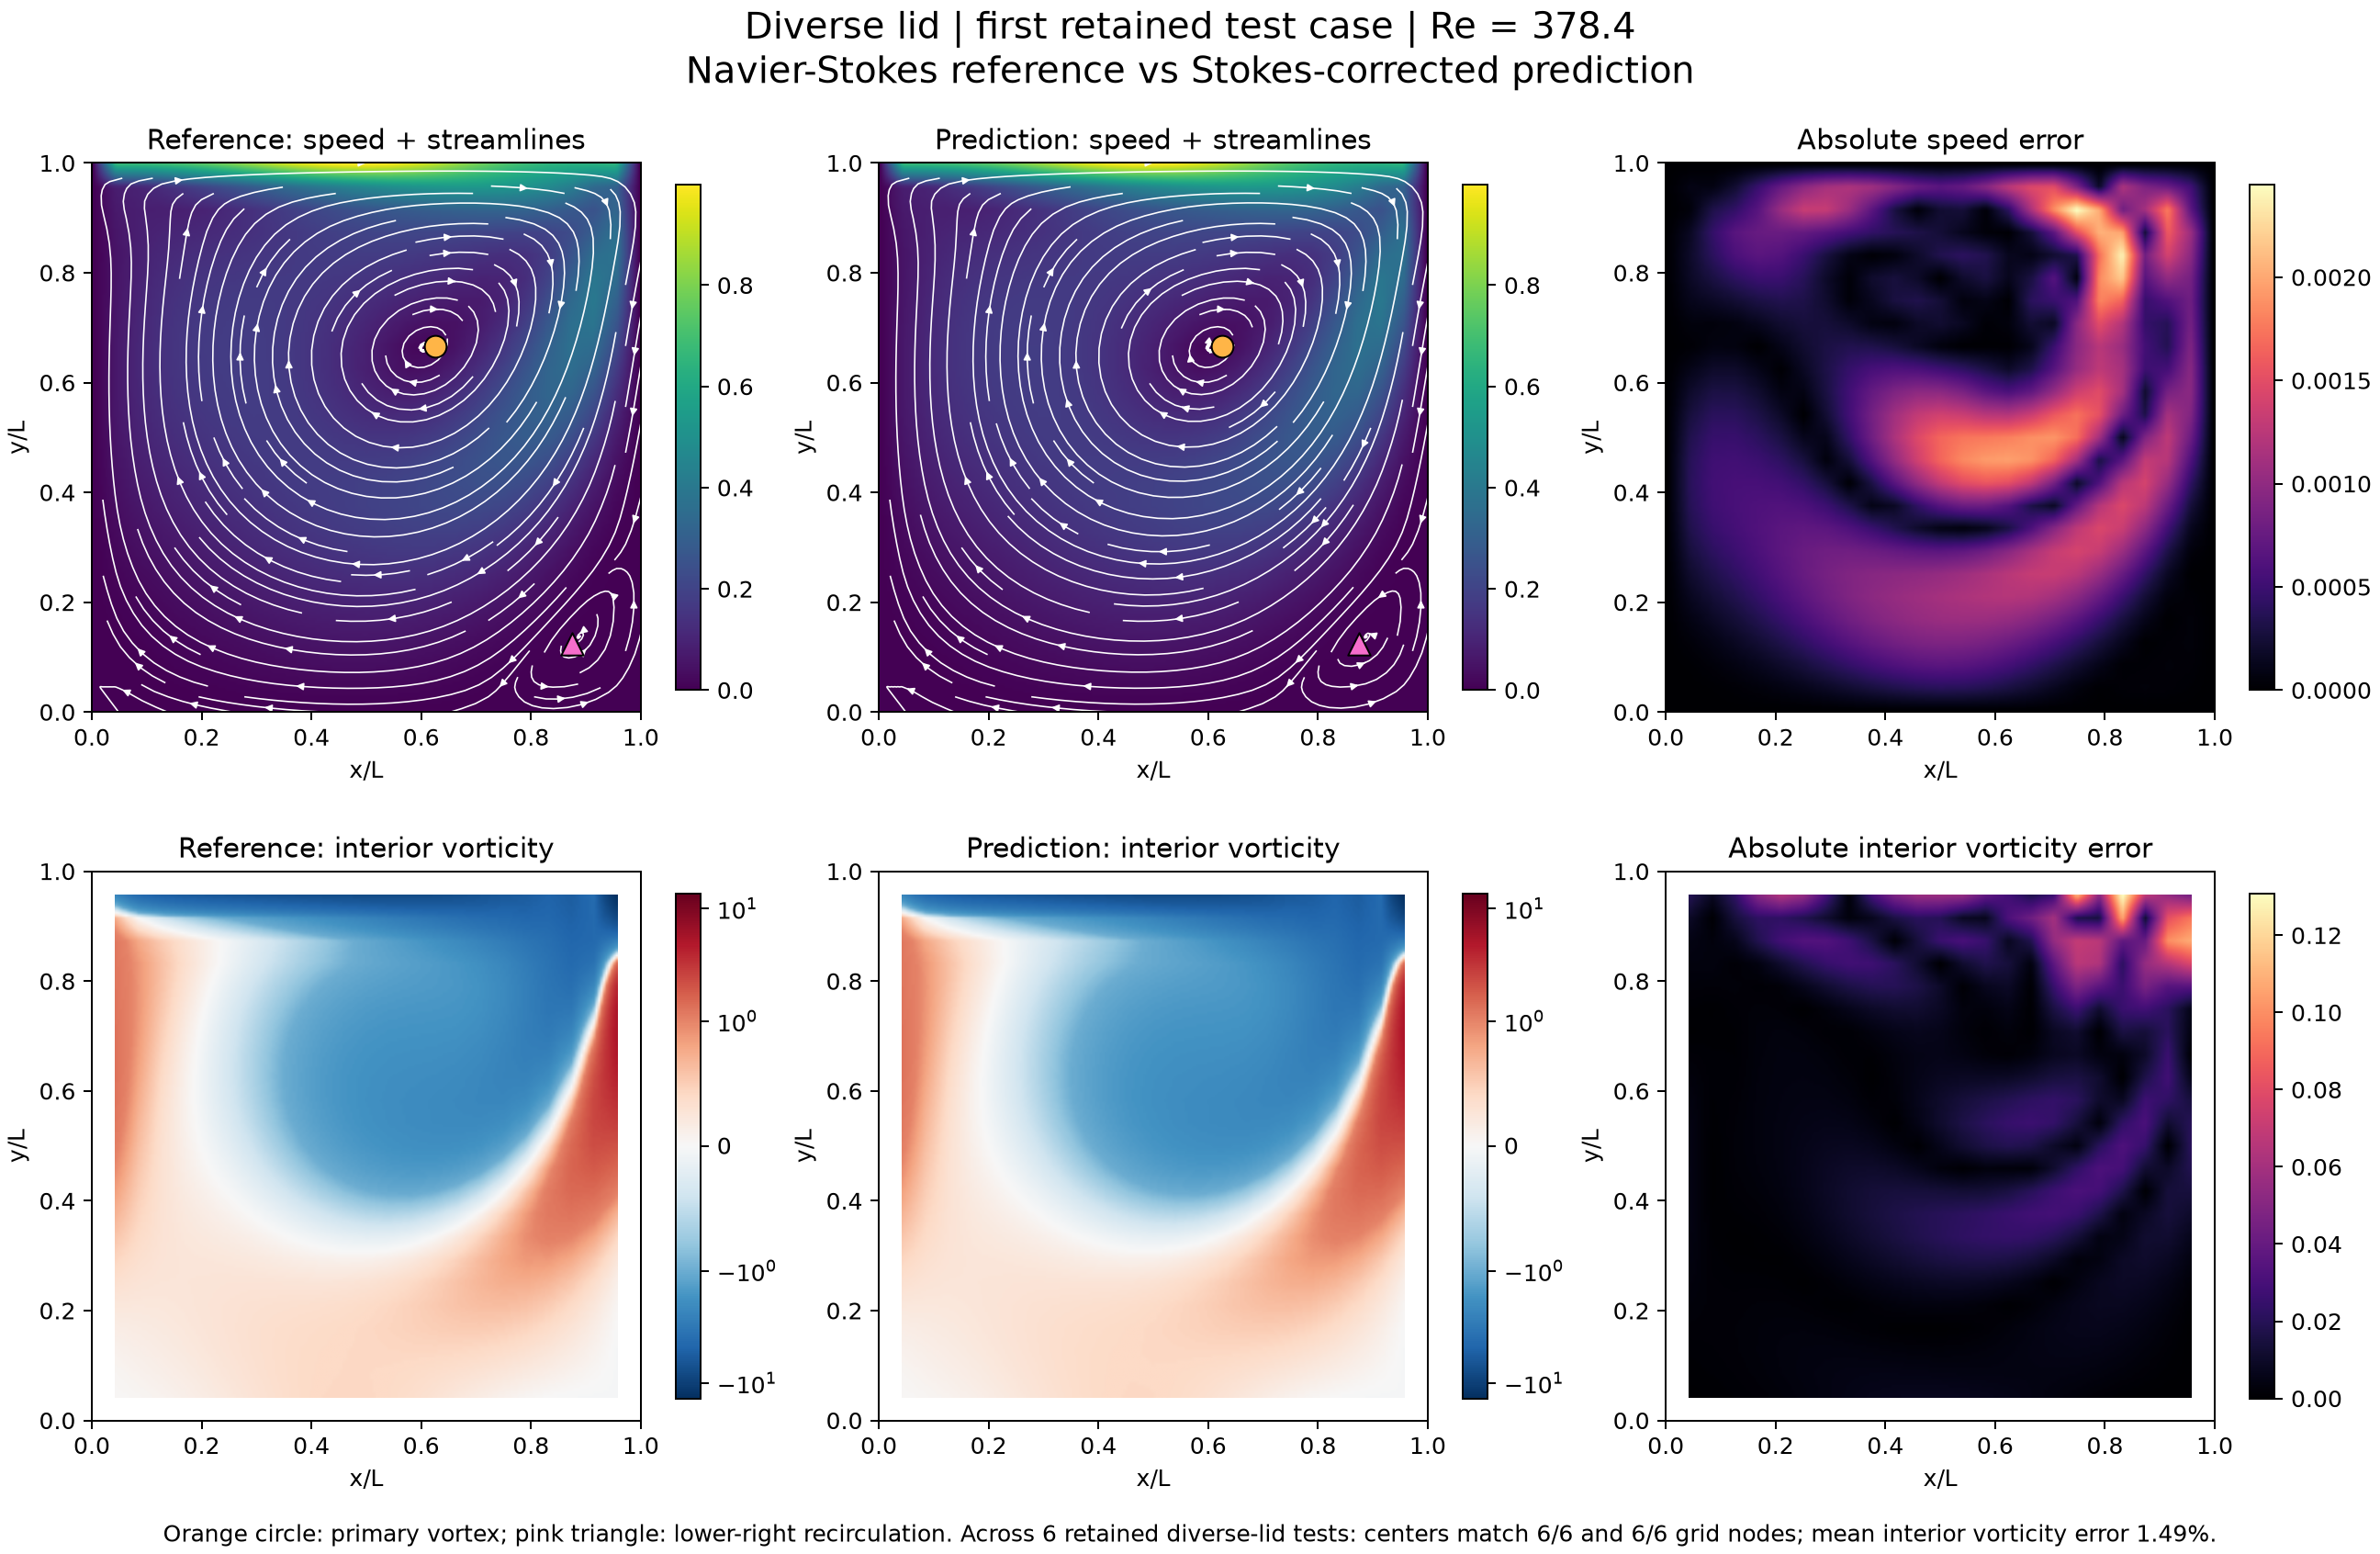

In [14]:
vortices = pd.read_csv(R/'vortex_comparison.csv')
display(vortices.groupby('family')['interior_vorticity_rel_l2'].agg(['mean','max']).round(4))
display(Image(filename=str(ROOT/'figures/Cavity_constant_streamlines_vorticity.png')))
display(Image(filename=str(ROOT/'figures/Cavity_diverse_streamlines_vorticity.png')))

## 10. Interpretation and claim boundary

The diverse-lid model generalizes much better across boundary families and OOD groups. Constant-only training remains poor on diverse lids because it never learns dependence on lid shape. The best retained mean errors are 0.107% for constant-to-constant and 0.917% for diverse-to-diverse velocity prediction.

These are same-grid surrogate errors against an educational finite-difference solver. The study does not establish mesh-independent CFD accuracy, a new neural architecture, or greater physical fidelity than the numerical labels. The useful result is narrower: an actual Stokes field is a strong low-fidelity coordinate for learning the nonlinear Navier-Stokes correction when the training boundary conditions span the intended use.

## 11. Numerical-grid refinement

The [51 × 51 validation companion](W4_Lab4_Grid51_Validation.ipynb) recomputes all 184 Navier–Stokes and matched Stokes cases, retrains the selected POD correction, and compares the numerical reference and surrogate errors against this 25 × 25 baseline. The [three-page PDF addendum](../../lectures/week04_2_grid51_validation.pdf) includes the speed, streamline and vorticity figures. The 25-to-51 change remains substantial, so neither grid establishes mesh-independent CFD accuracy.